# spikecurate: the classifier API

`demo_01.ipynb` runs the whole pipeline end to end via `spikecurate.run()`.
This notebook is a focused walkthrough of what's underneath it -
`FractionalLogisticClassifier`'s own scikit-learn-flavored API - so you can
use it directly: retrain on a different dataset, re-predict on new units
without redoing waveform extraction, or evaluate a model you loaded/built
some other way.

Covers:

- `model.train(dataset)` - fit on the full labeled dataset
- `model.crossval_evaluate(dataset)` - cross-validated precision/recall
- `model.predict(features)` - classify units, labeled or not
- `model.score(dataset)` - precision/recall of the trained model against known labels

**Setup**: this notebook reuses the same real `spikebias` dataset and
pre-computed single-unit `WaveformExtractor` as `demo_01.ipynb`, purely to
get to a `dataset` of engineered features quickly - the feature engineering
itself isn't the point here, so this section is intentionally terse. See
`demo_01.ipynb` for what each step does.

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import spikeinterface as si
import spikeinterface.preprocessing as spre
from spikeinterface.curation import remove_excess_spikes
from matplotlib import pyplot as plt
import spikecurate
from spikecurate.model import FractionalLogisticClassifier
from spikecurate.plotting import plot_precision_recall

print("spikeinterface", si.__version__)
print("spikecurate", spikecurate.__version__)

spikeinterface 0.100.8
spikecurate 0.1.0


## Get to a `dataset` (see `demo_01.ipynb` for details)

In [2]:
SPIKEBIAS_DATASET_DIR = "/home/steeve/steeve/epfl/code/spikebias"
EXP, SORTER = "NS", "KS4"
DURATION_SEC = 600
WE_JOB_KWARGS = dict(n_jobs=20, chunk_duration="1s", progress_bar=True)

RECORDING_PATH = os.path.join(SPIKEBIAS_DATASET_DIR, "dataset/00_raw/recording_npx_spont/")
SORTING_KS4_PATH = os.path.join(SPIKEBIAS_DATASET_DIR, "dataset/01_intermediate/sorting/npx_spont/SortingKS4_10m/")
SORTING_TRUE_10MN = os.path.join(SPIKEBIAS_DATASET_DIR, "dataset/00_raw/ground_truth_npx_spont_10m")
WE_SINGLE_UNITS_PATH = os.path.join(
    SPIKEBIAS_DATASET_DIR, "dataset/01_intermediate/waveforms/npx_spont/SortingKS4_10m_single_units"
)
QUALITY_PATH = os.path.join(SPIKEBIAS_DATASET_DIR, "dataset/01_intermediate/analysis/sorting_quality/sorting_quality.csv")

In [ ]:
%%time

recording = si.load_extractor(RECORDING_PATH)
recording.set_property("location", recording.get_property("location")[:, :2])
recording = spre.highpass_filter(recording, freq_min=300)
recording = spre.common_reference(recording, reference="global", operator="median")

sorting_true = si.load_extractor(SORTING_TRUE_10MN)

sorting = si.load_extractor(SORTING_KS4_PATH)
sorting = remove_excess_spikes(sorting, recording)
sorting = sorting.frame_slice(start_frame=0, end_frame=recording.get_sampling_frequency() * DURATION_SEC)

single_unit_ids = sorting.unit_ids[np.where(sorting.get_property("KSLabel") == "good")[0]]
sorting_single_units = sorting.select_units(unit_ids=list(single_unit_ids))

we = si.WaveformExtractor.load_from_folder(WE_SINGLE_UNITS_PATH)  # pre-computed by demo_01.ipynb

# These are annotated by the user
good_unit_ids = [198, 199, 213, 214, 231, 240, 241, 247, 252, 254, 262, 269, 280, 284, 286, 292, 296, 297
, 299, 307, 316, 318, 172, 321, 166, 162, 42, 48, 53, 54, 58, 61, 76, 83, 84, 96
, 108, 109, 116, 117, 121, 122, 135, 142, 143, 146, 152, 160, 323, 328, 452, 453, 455, 459
, 460, 462, 465, 466, 472, 473, 477, 478, 479, 485, 487, 451, 325, 435, 342, 345, 358, 385
, 389, 391, 399, 401, 402, 410, 411, 413, 424, 426, 432, 438]

bad_unit_ids = [26, 158, 165, 183, 189, 193, 197, 201, 202, 207, 211, 221, 223, 227, 239, 249, 250, 263
, 264, 270, 277, 281, 283, 289, 157, 291, 149, 130, 29, 40, 41, 45, 55, 56, 60, 66
, 71, 77, 81, 85, 86, 90, 102, 104, 105, 110, 113, 120, 126, 127, 128, 140, 300, 302
, 304, 442, 445, 446, 448, 449, 450, 458, 461, 463, 469, 470, 471, 475, 482, 483, 484, 490
, 440, 429, 420, 408, 308, 310, 315, 319, 333, 339, 341, 346, 348, 350, 365, 368, 374, 380
, 381, 384, 386, 390, 393, 396, 398, 400, 405, 371]

CPU times: user 19.2 ms, sys: 27 ms, total: 46.2 ms
Wall time: 45.9 ms


/home/steeve/steeve/epfl/code/spikebias/envs/spikebias/lib/python3.9/site-packages/spikeinterface/core/base.py:1079: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.101.2 is recommended
  warnings.warn(


In [5]:
%%time

data = spikecurate.load_dataset(
    single_unit_ids, good_unit_ids, bad_unit_ids, sorting_single_units, sorting_true, we,
    load_qm_if_exists=False, job_kwargs=WE_JOB_KWARGS,
)
dataset = data["dataset"]
predictors = data["predictors"]
print(dataset.shape, "units x", len(predictors), "predictors + quality_label")
dataset.head()

extract amplitudes:   0%|          | 0/2058 [00:00<?, ?it/s]

  0%|          | 0/184 [00:00<?, ?it/s]

extract amplitudes:   0%|          | 0/2058 [00:00<?, ?it/s]

(184, 11) units x 10 predictors + quality_label
CPU times: user 10.7 s, sys: 3.81 s, total: 14.5 s
Wall time: 1min 17s


,amplitude_cutoff,firing_range,firing_rate,isi_violations_ratio,rp_contamination,rp_violations,sd_ratio,snr,silhouette,mad_ratio,quality_label
26,0.016846,0.8,0.177843,0.000000,0.000000,0,1.057312,3.616185,NaN,0.982328,0.0
29,0.002158,0.4,0.069971,0.000000,0.000000,0,2.619702,5.599004,NaN,2.007412,0.0
40,0.004352,4.0,1.003402,0.160873,0.280708,1,3.255518,3.085943,0.033388,2.445883,0.0
41,0.004089,1.6,0.324587,0.000000,0.000000,0,2.067590,2.072921,0.053211,1.859907,0.0
42,0.000178,3.2,0.844510,0.227104,0.435475,1,1.000547,3.889037,0.116835,0.870333,1.0


## Instantiate the classifier

`FractionalLogisticClassifier` just needs the predictor column names - it
builds its GLM formula from them (`quality_label ~ 1 + <predictors>`) and
doesn't touch `dataset` until you call `train()` or `crossval_evaluate()`.

In [5]:
model = FractionalLogisticClassifier(predictors, thresh=0.8)
print(model.formula)
print("is_trained:", model.is_trained)

quality_label ~ 1 + amplitude_cutoff + firing_range + firing_rate + isi_violations_ratio + rp_contamination + rp_violations + sd_ratio + snr + silhouette + mad_ratio
is_trained: False


## `model.crossval_evaluate(dataset)`

Repeatedly splits `dataset` into a random 75/25 train/test partition (one
split per seed, 100 seeds by default), fits a **fresh** GLM on each
training split, and reports precision/recall on the held-out test split.
This is the honest estimate of how well the classifier generalizes to
units it wasn't trained on - it does **not** use or affect `model.train()`
or `model.predict()`; each fold's fit is thrown away after scoring it.

In [6]:
%%time

crossval_results = model.crossval_evaluate(dataset, seeds=np.arange(0, 100, 1))
crossval_results["metric_stats"]

CPU times: user 1.01 s, sys: 0 ns, total: 1.01 s
Wall time: 1.01 s


{'precision_median': 0.8888888888888888,
 'precision_std': 0.08995270167684924,
 'precision_ci95': 0.017630729528662452,
 'recall_median': 0.5909090909090909,
 'recall_std': 0.12449134951248518,
 'recall_ci95': 0.024400304504447096}

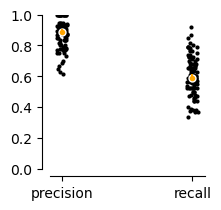

In [ ]:
%%time

fig, ax = plt.subplots(1, 1, figsize=(2, 2))
plot_precision_recall(ax, crossval_results["metric_data"])
plt.show()

## `model.train(dataset)`

Fits **one** GLM on the *entire* `dataset` (with a regularized warm-start,
then an unregularized refit to recover p-values) and stores the fitted
result - and the fitted feature scaler, if `scale_data=True` - on the
instance. Returns `self`, so it chains: `model.train(dataset).predict(...)`.

This is the model you'd actually deploy to classify new units - as opposed
to `crossval_evaluate`'s fold models, which only ever existed to be
scored and discarded.

In [ ]:
%%time 

model.train(dataset)
print("is_trained:", model.is_trained)
print(model.result_.summary())

is_trained: True
                 Generalized Linear Model Regression Results                  
Dep. Variable:          quality_label   No. Observations:                  182
Model:                            GLM   Df Residuals:                      171
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -53.201
Date:                Fri, 28 Aug 2026   Deviance:                       106.40
Time:                        13:31:33   Pearson chi2:                     84.6
No. Iterations:                     1   Pseudo R-squ. (CS):             0.5488
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept      

/home/steeve/steeve/epfl/code/spikebias/envs/spikebias/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:1464: UserWarning: Elastic net fitting did not converge
  warnings.warn("Elastic net fitting did not converge")


## `model.predict(features)`

Classifies units from their quality-metric features alone - `features`
just needs unit id as its index and the columns in `model.predictors`; a
`quality_label` column isn't required (and is ignored if present). That's
the point: predicting labels for units you *don't* already have labels
for.

Below: predicting on 5 units already in the training set, purely to show
the output shape (`probability`, `predicted_label`, `predicted_quality`).

In [9]:
example_ids = list(dataset.index[:5])
predictions = model.predict(dataset.loc[example_ids, predictors])
predictions

,probability,predicted_label,predicted_quality
26,NaN,0,bad
29,NaN,0,bad
40,0.006578,0,bad
41,0.006993,0,bad
42,0.913419,1,good


### `predict()` raises before `train()`

A fresh, untrained model can't predict - `predict()` raises `RuntimeError`
rather than silently returning garbage.

In [10]:
untrained_model = FractionalLogisticClassifier(predictors)
try:
    untrained_model.predict(dataset.loc[example_ids, predictors])
except RuntimeError as e:
    print("RuntimeError:", e)

RuntimeError: call train() before predict()


## `model.score(dataset)`

Precision/recall of the **trained** model against a dataset's own known
`quality_label` column - one fit, scored on whatever you pass in. Scoring
it against the very data it was trained on (below) is expected to look
better than `crossval_evaluate`'s numbers above, since here the model has
already seen every unit during training - that gap is exactly why
cross-validation, not self-scoring, is the number to trust for
generalization.

In [11]:
self_score = model.score(dataset)
print("self-score (trained on and scored against the same data):", self_score)
print("crossval median (held-out folds):", crossval_results["metric_stats"])

self-score (trained on and scored against the same data): {'precision': 0.9803921568627451, 'recall': 0.5952380952380952}
crossval median (held-out folds): {'precision_median': 0.8888888888888888, 'precision_std': 0.08995270167684924, 'precision_ci95': 0.017630729528662452, 'recall_median': 0.5909090909090909, 'recall_std': 0.12449134951248518, 'recall_ci95': 0.024400304504447096}
